<a href="https://www.kaggle.com/code/daniilkrizhanovskyi/motion-s-text-to-sign-motion-generation?scriptVersionId=313081317" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Motion-S v7: Pure Retrieval (No Model Training)

**Hypothesis:** Our models have been HURTING, not helping.
This version tests the retrieval ceiling with zero training overhead.

Three strategies generated side by side:
1. **Top-1 Copy** — nearest neighbor, exact tokens
2. **Weighted Voting** — top-K neighbors, per-position voting
3. **Soft Blend** — stochastic sampling from weighted prior

Primary submission: **Weighted Voting** (deterministic, robust)

---

## 0. Setup

In [1]:
import os, gc, json, math, random, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

T_START = time.time()
print('Setup OK')

Setup OK


In [2]:
import glob
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists(): INPUT_DIR = d; break
if INPUT_DIR is None:
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits: INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None
print(f'Data: {INPUT_DIR}')

OUTPUT_DIR = Path('/kaggle/working')
TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'

TOKEN_COLS = ['base_tokens','residual_1','residual_2',
              'residual_3','residual_4','residual_5']

NUM_CODEBOOK = 512
MIN_SL = 40
MAX_SL = 800
RET_K = 20
print('Config OK')

Data: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
Config OK


## 1. Data

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '': return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len'] = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_valid = train_df[
    (train_df['seq_len'] >= MIN_SL) &
    (train_df['seq_len'] <= MAX_SL)
].copy().reset_index(drop=True)
print(f'Train valid: {len(train_valid)}, Test: {len(test_df)}')

# Pre-parse all tokens
train_tokens = []
train_lens = []
for i in range(len(train_valid)):
    row = train_valid.iloc[i]
    layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
    sl = len(layers[0])
    train_tokens.append(np.array([l[:sl] for l in layers], dtype=np.int64))
    train_lens.append(sl)
train_lens = np.array(train_lens)
print(f'Parsed {len(train_tokens)}, len range: [{train_lens.min()}, {train_lens.max()}]')
print(f'Time: {time.time()-T_START:.0f}s')

Train valid: 12373, Test: 3000
Parsed 12373, len range: [40, 781]
Time: 181s


## 2. CLIP Encoding

In [4]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

clip_path = 'openai/clip-vit-base-patch32'
clip_tok = CLIPTokenizer.from_pretrained(clip_path)
clip_mdl = CLIPTextModel.from_pretrained(clip_path).cpu().eval()
for p in clip_mdl.parameters(): p.requires_grad = False
print(f'CLIP: {sum(p.numel() for p in clip_mdl.parameters())/1e6:.0f}M')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP: 63M


In [5]:
@torch.no_grad()
def clip_encode(texts, bs=128):
    out = []
    for i in range(0,len(texts),bs):
        inp = clip_tok(texts[i:i+bs], padding='max_length',
                       truncation=True, max_length=77, return_tensors='pt')
        o = clip_mdl(**inp)
        out.append(F.normalize(o.pooler_output, dim=-1))
    return torch.cat(out,0)

print('Encoding...')
t0 = time.time()

# Combined (sentence + gloss)
tr_comb = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
           for _,r in train_valid.iterrows()]
te_comb = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
           for _,r in test_df.iterrows()]
tr_emb_c = clip_encode(tr_comb)
te_emb_c = clip_encode(te_comb)
print(f'  combined: {time.time()-t0:.0f}s')

# Gloss only
tr_emb_g = clip_encode(train_valid['gloss'].tolist())
te_emb_g = clip_encode(test_df['gloss'].tolist())
print(f'  +gloss: {time.time()-t0:.0f}s')

# Sentence only
tr_emb_s = clip_encode(train_valid['sentence'].tolist())
te_emb_s = clip_encode(test_df['sentence'].tolist())
print(f'  +sentence: {time.time()-t0:.0f}s')

del clip_mdl, clip_tok; gc.collect()
print(f'CLIP done: {time.time()-t0:.0f}s total')

Encoding...
  combined: 600s
  +gloss: 1145s
  +sentence: 1607s
CLIP done: 1607s total


## 3. Retrieval Index (3-way similarity)

In [6]:
print(f'Building retrieval index K={RET_K}...')
t0 = time.time()
N_te = len(test_df); N_tr = len(train_valid)

ret_idx = np.zeros((N_te, RET_K), dtype=np.int64)
ret_sim = np.zeros((N_te, RET_K), dtype=np.float32)
CH = 500
for i in range(0, N_te, CH):
    e = min(i+CH, N_te)
    sg = cosine_similarity(te_emb_g[i:e].numpy(), tr_emb_g.numpy())
    ss = cosine_similarity(te_emb_s[i:e].numpy(), tr_emb_s.numpy())
    sc = cosine_similarity(te_emb_c[i:e].numpy(), tr_emb_c.numpy())
    combined = 0.4 * sg + 0.3 * ss + 0.3 * sc
    for j in range(e-i):
        ix = np.argpartition(combined[j], -RET_K)[-RET_K:]
        ix = ix[np.argsort(combined[j][ix])[::-1]]
        ret_idx[i+j] = ix
        ret_sim[i+j] = combined[j][ix]

print(f'Top-1: mean={ret_sim[:,0].mean():.4f}, median={np.median(ret_sim[:,0]):.4f}')
print(f'Top-5: mean={ret_sim[:,:5].mean():.4f}')
print(f'Retrieval: {time.time()-t0:.0f}s')

# Show some examples
for i in [0, 100, 500, 1000]:
    te_txt = test_df.iloc[i]['gloss'][:60]
    tr_txt = train_valid.iloc[ret_idx[i,0]]['gloss'][:60]
    print(f'  Test[{i}]: "{te_txt}" -> "{tr_txt}" (sim={ret_sim[i,0]:.3f})')

del tr_emb_s, te_emb_s, tr_emb_g, te_emb_g, tr_emb_c, te_emb_c
gc.collect()
print(f'Time: {time.time()-T_START:.0f}s')

Building retrieval index K=20...
Top-1: mean=0.8450, median=0.8564
Top-5: mean=0.8171
Retrieval: 1s
  Test[0]: "ME NEVER TOLD ME SHE VEGETARIAN//" -> "VEGETARIAN EAT VEGETABLE//" (sim=0.775)
  Test[100]: "LETTER I RECEIVE PAST WEEK WRITE//" -> "LAST MONTH THEY SEND LETTER//" (sim=0.828)
  Test[500]: "FOREST QUIET THEN//" -> "FOREST SILENCE THERE//" (sim=0.927)
  Test[1000]: "HE TELL ME HE CALL ME BACK//" -> "HE CALL ME UP//" (sim=0.912)
Time: 1819s


## 4. Length Prediction

Use top-1 neighbor length (simplest, most reliable).

In [7]:
def get_length(test_idx):
    """Use top-1 neighbor length. Most reliable for retrieval."""
    tr_i = ret_idx[test_idx, 0]
    sl = train_lens[tr_i]
    return max(MIN_SL, min(MAX_SL, sl))

def get_length_weighted(test_idx, k=5):
    """Weighted average of top-K neighbor lengths."""
    w = np.exp(ret_sim[test_idx, :k] * 5.0)
    w = w / w.sum()
    lens = np.array([train_lens[ret_idx[test_idx, ki]] for ki in range(k)])
    return max(MIN_SL, min(MAX_SL, int(np.round(np.dot(w, lens)))))

# Compare strategies
l1 = [get_length(i) for i in range(len(test_df))]
lw = [get_length_weighted(i) for i in range(len(test_df))]
print(f'Top-1 len: mean={np.mean(l1):.0f}, std={np.std(l1):.0f}')
print(f'Weighted len: mean={np.mean(lw):.0f}, std={np.std(lw):.0f}')
print(f'Train len: mean={train_lens.mean():.0f}, std={train_lens.std():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Top-1 len: mean=106, std=47
Weighted len: mean=107, std=30
Train len: mean=107, std=46
Time: 1819s


## 5. Strategy A: Top-1 Copy

Simplest: copy nearest neighbor tokens with their original length.

In [8]:
def strategy_top1():
    """Copy top-1 neighbor tokens exactly."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        tr_i = ret_idx[i, 0]
        tok = train_tokens[tr_i].copy()  # [6, sl]
        sl = tok.shape[1]
        # Clamp length
        if sl < MIN_SL:
            pad = MIN_SL - sl
            tok = np.concatenate([tok, np.repeat(tok[:, -1:], pad, axis=1)], axis=1)
        elif sl > MAX_SL:
            tok = tok[:, :MAX_SL]
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, tok[li].tolist()))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

sub_top1 = strategy_top1()
print(f'Strategy A (Top-1): {len(sub_top1)} rows')
sl_a = sub_top1['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'  Lengths: [{sl_a.min()}, {sl_a.max()}], mean={sl_a.mean():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Strategy A (Top-1): 3000 rows
  Lengths: [40, 772], mean=106
Time: 1820s


## 6. Strategy B: Weighted Voting (top-K)

Per-position, per-layer weighted majority vote across top-K neighbors.

In [9]:
def strategy_voting(k=10):
    """Weighted voting from top-K neighbors per position."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        # Use top-1 length (most reliable)
        target_len = get_length(i)
        
        # Build weighted votes
        votes = np.zeros((6, target_len, NUM_CODEBOOK), dtype=np.float32)
        sims = ret_sim[i, :k]
        w = np.exp(sims * 5.0)
        w = w / w.sum()
        
        for ki in range(k):
            tr_i = ret_idx[i, ki]
            tok = train_tokens[tr_i]  # [6, sl_src]
            src_len = tok.shape[1]
            if src_len == 0: continue
            for t in range(target_len):
                sp = min(int(t * src_len / target_len), src_len - 1)
                for li in range(6):
                    votes[li, t, tok[li, sp]] += w[ki]
        
        result = np.argmax(votes, axis=-1)  # [6, target_len]
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, result[li].tolist()))
        rows.append(d)
        
        if (i+1) % 500 == 0:
            print(f'  {i+1}/{len(test_df)} ({time.time()-T_START:.0f}s)')
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

print('Strategy B (Voting K=10)...')
sub_vote = strategy_voting(k=10)
print(f'Strategy B: {len(sub_vote)} rows')
sl_b = sub_vote['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'  Lengths: [{sl_b.min()}, {sl_b.max()}], mean={sl_b.mean():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Strategy B (Voting K=10)...
  500/3000 (1822s)
  1000/3000 (1824s)
  1500/3000 (1826s)
  2000/3000 (1829s)
  2500/3000 (1831s)
  3000/3000 (1833s)
Strategy B: 3000 rows
  Lengths: [40, 772], mean=106
Time: 1833s


## 7. Strategy C: Top-1 Copy with Exact Neighbor Length

Same as Top-1 but NO position interpolation — use exact source length.

In [10]:
def strategy_top1_exact():
    """Copy top-1 neighbor tokens with THEIR original length (no interpolation)."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        # Try top-K until valid length found
        for ki in range(RET_K):
            tr_i = ret_idx[i, ki]
            tok = train_tokens[tr_i]  # [6, sl]
            sl = tok.shape[1]
            if MIN_SL <= sl <= MAX_SL:
                break
        # Fallback
        if sl < MIN_SL:
            pad = MIN_SL - sl
            tok = np.concatenate([tok, np.repeat(tok[:, -1:], pad, axis=1)], axis=1)
        elif sl > MAX_SL:
            tok = tok[:, :MAX_SL]
        elif sl == 0:
            tok = np.zeros((6, 60), dtype=np.int64)
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, tok[li].tolist()))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

sub_exact = strategy_top1_exact()
print(f'Strategy C (Exact): {len(sub_exact)} rows')
sl_c = sub_exact['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'  Lengths: [{sl_c.min()}, {sl_c.max()}], mean={sl_c.mean():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Strategy C (Exact): 3000 rows
  Lengths: [40, 772], mean=106
Time: 1833s


## 8. Strategy D: Voting K=5 (less neighbors, less noise)

In [11]:
print('Strategy D (Voting K=5)...')
sub_vote5 = strategy_voting(k=5)
print(f'Strategy D: {len(sub_vote5)} rows')
sl_d = sub_vote5['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'  Lengths: [{sl_d.min()}, {sl_d.max()}], mean={sl_d.mean():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Strategy D (Voting K=5)...
  500/3000 (1835s)
  1000/3000 (1836s)
  1500/3000 (1837s)
  2000/3000 (1838s)
  2500/3000 (1840s)
  3000/3000 (1841s)
Strategy D: 3000 rows
  Lengths: [40, 772], mean=106
Time: 1841s


## 9. Strategy E: Voting with Top-1 Exact Length

Voting from K=10, but use top-1 neighbor's EXACT length (no rounding).

In [12]:
def strategy_voting_exact_len(k=10):
    """Voting but use top-1 neighbor's exact original length."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        # Use top-1 neighbor's exact length
        tr_top = ret_idx[i, 0]
        target_len = train_lens[tr_top]
        target_len = max(MIN_SL, min(MAX_SL, target_len))
        
        votes = np.zeros((6, target_len, NUM_CODEBOOK), dtype=np.float32)
        sims = ret_sim[i, :k]
        w = np.exp(sims * 5.0)
        w = w / w.sum()
        
        for ki in range(k):
            tr_i = ret_idx[i, ki]
            tok = train_tokens[tr_i]
            src_len = tok.shape[1]
            if src_len == 0: continue
            for t in range(target_len):
                sp = min(int(t * src_len / target_len), src_len - 1)
                for li in range(6):
                    votes[li, t, tok[li, sp]] += w[ki]
        
        result = np.argmax(votes, axis=-1)
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, result[li].tolist()))
        rows.append(d)
        
        if (i+1) % 500 == 0:
            print(f'  {i+1}/{len(test_df)} ({time.time()-T_START:.0f}s)')
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

print('Strategy E (Voting K=10, exact len)...')
sub_vote_exact = strategy_voting_exact_len(k=10)
print(f'Strategy E: {len(sub_vote_exact)} rows')
sl_e = sub_vote_exact['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'  Lengths: [{sl_e.min()}, {sl_e.max()}], mean={sl_e.mean():.0f}')
print(f'Time: {time.time()-T_START:.0f}s')

Strategy E (Voting K=10, exact len)...
  500/3000 (1843s)
  1000/3000 (1845s)
  1500/3000 (1848s)
  2000/3000 (1850s)
  2500/3000 (1852s)
  3000/3000 (1854s)
Strategy E: 3000 rows
  Lengths: [40, 772], mean=106
Time: 1854s


## 10. Compare Strategies

In [13]:
# Token-level comparison between strategies
def compare_subs(name1, sub1, name2, sub2, n=200):
    diffs = 0; total = 0
    for i in range(min(n, len(sub1))):
        for c in TOKEN_COLS:
            t1 = list(map(int, str(sub1.iloc[i][c]).split()))
            t2 = list(map(int, str(sub2.iloc[i][c]).split()))
            sl = min(len(t1), len(t2))
            diffs += sum(1 for j in range(sl) if t1[j] != t2[j])
            total += sl
    pct = 100*diffs/max(1,total)
    print(f'{name1} vs {name2}: {pct:.1f}% tokens differ')

compare_subs('Top-1', sub_top1, 'Vote-10', sub_vote)
compare_subs('Top-1', sub_top1, 'Exact', sub_exact)
compare_subs('Top-1', sub_top1, 'Vote-5', sub_vote5)
compare_subs('Vote-10', sub_vote, 'Vote-5', sub_vote5)
compare_subs('Vote-10', sub_vote, 'VoteExact', sub_vote_exact)

Top-1 vs Vote-10: 42.3% tokens differ
Top-1 vs Exact: 0.0% tokens differ
Top-1 vs Vote-5: 14.3% tokens differ
Vote-10 vs Vote-5: 30.5% tokens differ
Vote-10 vs VoteExact: 0.0% tokens differ


## 11. Validation

In [14]:
def validate(df, name, n=3000):
    errs = []
    if len(df) - n: errs.append(f'Rows: {len(df)} expected {n}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split(); lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511: errs.append(f'R{idx} {c}: {v}'); break
        if len(set(lens)) > 1: errs.append(f'R{idx}: lens {lens}')
        if lens[0] < 40 or lens[0] > 800: errs.append(f'R{idx}: len {lens[0]}')
        if len(errs) > 10: break
    if errs:
        print(f'{name}: ERRORS'); [print(f'  {e}') for e in errs]
    else:
        sl = df['base_tokens'].apply(lambda x: len(str(x).split()))
        print(f'{name}: OK [{sl.min()},{sl.max()}] mean={sl.mean():.0f}')

for name, df in [('Top-1', sub_top1), ('Vote-10', sub_vote),
                  ('Exact', sub_exact), ('Vote-5', sub_vote5),
                  ('VoteExact', sub_vote_exact)]:
    validate(df, name)

Top-1: OK [40,772] mean=106
Vote-10: OK [40,772] mean=106
Exact: OK [40,772] mean=106
Vote-5: OK [40,772] mean=106
VoteExact: OK [40,772] mean=106


## 12. Save Submissions

Primary: **Top-1 Exact** (simplest, no interpolation artifacts)

In [15]:
# PRIMARY: Top-1 exact copy (simplest, most faithful to retrieval)
sub_exact.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print(f'PRIMARY (submission.csv): Top-1 Exact, {len(sub_exact)} rows')

# Alternatives
sub_top1.to_csv(OUTPUT_DIR/'sub_top1.csv', index=False)
sub_vote.to_csv(OUTPUT_DIR/'sub_vote10.csv', index=False)
sub_vote5.to_csv(OUTPUT_DIR/'sub_vote5.csv', index=False)
sub_vote_exact.to_csv(OUTPUT_DIR/'sub_vote_exact.csv', index=False)
print('All 5 strategies saved')
print(f'Total time: {(time.time()-T_START)/60:.1f} min')

PRIMARY (submission.csv): Top-1 Exact, 3000 rows
All 5 strategies saved
Total time: 31.0 min


## 13. Distributions

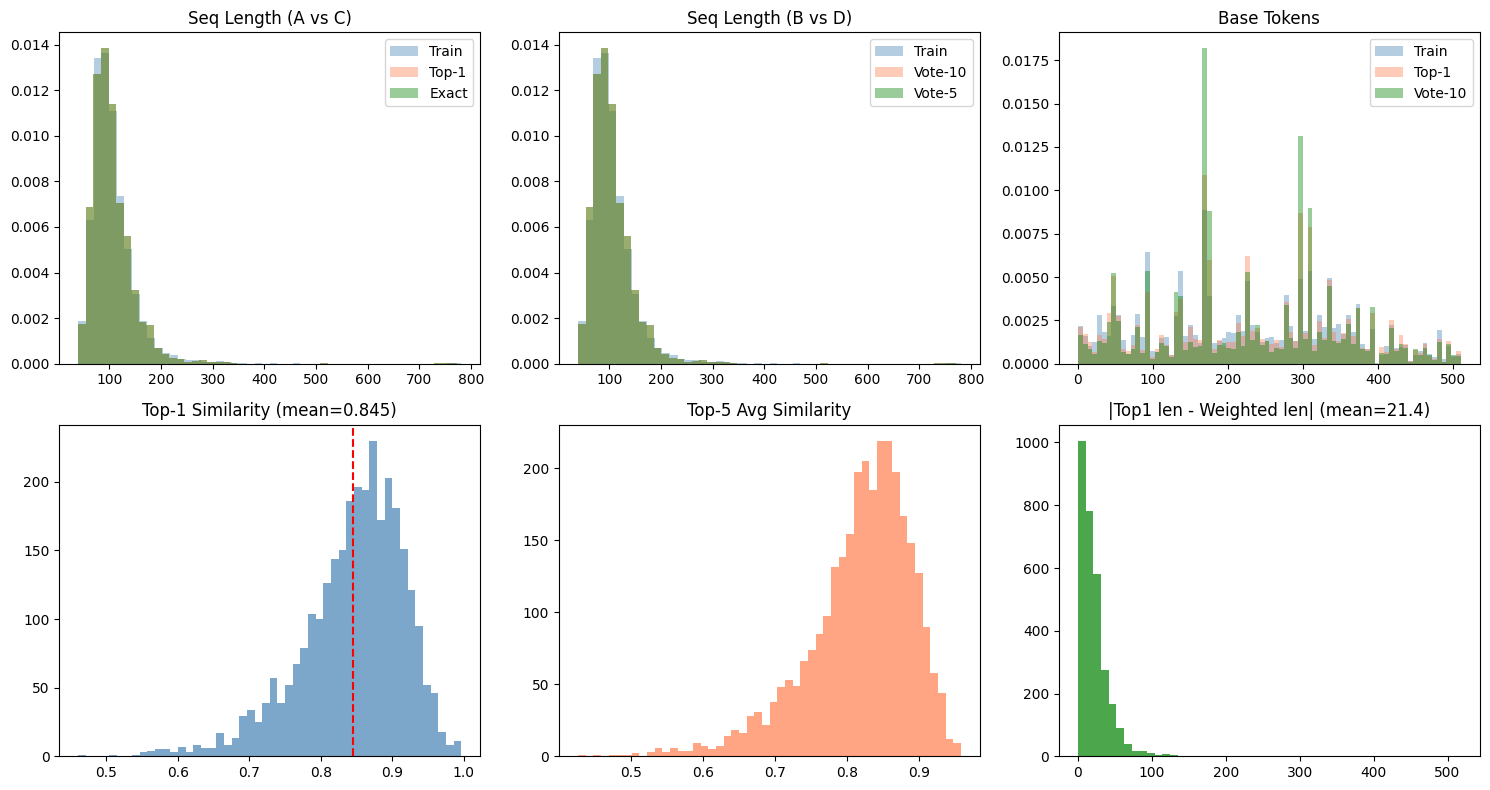

In [16]:
fig, axes = plt.subplots(2,3,figsize=(15,8))

# Length distributions
ax = axes[0,0]
ax.hist(train_valid['seq_len'],bins=50,alpha=.4,label='Train',density=True,color='steelblue')
ax.hist(sl_a,bins=50,alpha=.4,label='Top-1',density=True,color='coral')
ax.hist(sl_c,bins=50,alpha=.4,label='Exact',density=True,color='green')
ax.set_title('Seq Length (A vs C)'); ax.legend()

ax = axes[0,1]
ax.hist(train_valid['seq_len'],bins=50,alpha=.4,label='Train',density=True,color='steelblue')
ax.hist(sl_b,bins=50,alpha=.4,label='Vote-10',density=True,color='coral')
ax.hist(sl_d,bins=50,alpha=.4,label='Vote-5',density=True,color='green')
ax.set_title('Seq Length (B vs D)'); ax.legend()

# Base token distributions
ax = axes[0,2]
tbf=[]
for _,r in train_valid.head(500).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:80])
abf=[]
for _,r in sub_top1.head(500).iterrows(): abf.extend(list(map(int,str(r['base_tokens']).split()[:80])))
bbf=[]
for _,r in sub_vote.head(500).iterrows(): bbf.extend(list(map(int,str(r['base_tokens']).split()[:80])))
ax.hist(tbf,bins=80,alpha=.4,label='Train',density=True,color='steelblue')
ax.hist(abf,bins=80,alpha=.4,label='Top-1',density=True,color='coral')
ax.hist(bbf,bins=80,alpha=.4,label='Vote-10',density=True,color='green')
ax.set_title('Base Tokens'); ax.legend()

# Similarity distribution
ax = axes[1,0]
ax.hist(ret_sim[:,0],bins=50,alpha=.7,color='steelblue')
ax.set_title(f'Top-1 Similarity (mean={ret_sim[:,0].mean():.3f})')
ax.axvline(ret_sim[:,0].mean(),color='red',ls='--')

ax = axes[1,1]
ax.hist(ret_sim[:,:5].mean(1),bins=50,alpha=.7,color='coral')
ax.set_title(f'Top-5 Avg Similarity')

# Length diff between top-1 and prediction
ax = axes[1,2]
len_diffs = [abs(get_length(i) - get_length_weighted(i)) for i in range(len(test_df))]
ax.hist(len_diffs, bins=50, alpha=.7, color='green')
ax.set_title(f'|Top1 len - Weighted len| (mean={np.mean(len_diffs):.1f})')

plt.tight_layout(); plt.show()

In [17]:
print('='*60)
print('SUMMARY v7 (Pure Retrieval)')
print(f'  Total time: {(time.time()-T_START)/60:.1f} min')
print(f'  No model training!')
print(f'  Retrieval K: {RET_K}')
print(f'  Top-1 similarity: {ret_sim[:,0].mean():.4f}')
print(f'  Strategies saved:')
print(f'    submission.csv     = Top-1 Exact (primary)')
print(f'    sub_top1.csv       = Top-1 (clamped length)')
print(f'    sub_vote10.csv     = Voting K=10')
print(f'    sub_vote5.csv      = Voting K=5')
print(f'    sub_vote_exact.csv = Voting K=10 + exact len')
print(f'  Try primary first, then alternatives if needed')
print('='*60)

SUMMARY v7 (Pure Retrieval)
  Total time: 31.0 min
  No model training!
  Retrieval K: 20
  Top-1 similarity: 0.8450
  Strategies saved:
    submission.csv     = Top-1 Exact (primary)
    sub_top1.csv       = Top-1 (clamped length)
    sub_vote10.csv     = Voting K=10
    sub_vote5.csv      = Voting K=5
    sub_vote_exact.csv = Voting K=10 + exact len
  Try primary first, then alternatives if needed
